#Project Title: Credit Card Fraud Detection

In [1]:
#Libraries Required

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading Dataset

ccfd = pd.read_csv("https://raw.githubusercontent.com/ArchanaInsights/Datasets/refs/heads/main/credit_card_transactions.csv")

In [3]:
#Top 5 dataset details
ccfd.head()

,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
0,W963UK57,Mastercard,Utility bill,27214.0,2020-01-01 09:43:17,Patna,East,23.0,Female,94632.0,36369.65,100000.0,Unknown,Wednesday,No
1,V606KV56,American Express,Retail,83956.0,2020-01-03 16:26:13,Surat,West,49.0,Male,148118.0,89179.12,150000.0,Desktop,Friday,No
2,R531NU70,Visa,Transportation,193280.0,2020-01-04 03:40:49,Patna,East,NaN,Male,210921.0,106668.60,200000.0,Desktop,Saturday,No
3,T783GF79,RuPay,Online Shopping,167381.0,2020-01-04 14:56:24,Surat,West,52.0,Female,148070.0,173155.52,200000.0,Desktop,Saturday,Yes
4,K256ZN73,RuPay,Retail,81170.0,2020-01-04 17:26:47,Lucknow,North,37.0,Female,174470.0,52713.09,200000.0,Mobile,Saturday,No


In [4]:
#Numbers of Rows & Columns
ccfd.shape

(5000, 15)

In [5]:
#dataset information
ccfd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             5000 non-null   object 
 1   Card_Type                  4983 non-null   object 
 2   Merchant_Category          4978 non-null   object 
 3   Transaction_Amount         4994 non-null   float64
 4   Transaction_DateTime       5000 non-null   object 
 5   Location                   5000 non-null   object 
 6   Region                     5000 non-null   object 
 7   Cardholder_Age             4865 non-null   float64
 8   Cardholder_Gender          4911 non-null   object 
 9   Cardholder_Monthly_Income  4686 non-null   float64
 10  Cardholder_Average_Spend   4792 non-null   float64
 11  Credit_Limit               4991 non-null   float64
 12  Device_Type                4960 non-null   object 
 13  Day_of_Week                5000 non-null   objec

In [6]:
# Dataset with null values
ccfd.isnull().sum()

,0
Transaction_ID,0
Card_Type,17
Merchant_Category,22
Transaction_Amount,6
Transaction_DateTime,0
Location,0
Region,0
Cardholder_Age,135
Cardholder_Gender,89
Cardholder_Monthly_Income,314


##EDA(Exploratory Data Analysis)

In [7]:
# Analyze the distribution of categorical features
categorical_col = ccfd.select_dtypes(include= 'O')
for col in categorical_col:
  print(f'{col}:\n{ccfd[col].value_counts()}', end = '\n\n')

Transaction_ID:
Transaction_ID
D501WH15    1
W963UK57    1
V606KV56    1
R531NU70    1
T783GF79    1
           ..
G775SE48    1
Z447QC37    1
D105RT88    1
V841LV15    1
Q473IV29    1
Name: count, Length: 5000, dtype: int64

Card_Type:
Card_Type
Visa                1979
Mastercard          1540
RuPay                947
American Express     517
Name: count, dtype: int64

Merchant_Category:
Merchant_Category
Online Shopping    1019
Retail              959
Utility bill        521
Education           519
Entertainment       517
Healthcare          496
Dining              481
Transportation      466
Name: count, dtype: int64

Transaction_DateTime:
Transaction_DateTime
2023-12-30 11:41:36    1
2020-01-01 09:43:17    1
2020-01-03 16:26:13    1
2020-01-04 03:40:49    1
2020-01-04 14:56:24    1
                      ..
2020-01-07 19:39:07    1
2020-01-07 17:52:01    1
2020-01-07 09:57:23    1
2020-01-05 23:30:04    1
2020-01-05 19:55:48    1
Name: count, Length: 5000, dtype: int64

Location:
L

In [8]:
#Explore numerical features and spread.
numerical_col = ccfd.select_dtypes(exclude='O').columns
for num in numerical_col:
  print(f'{num}:\n {ccfd[num].unique()}', end ='\n\n')

Transaction_Amount:
 [ 27214.  83956. 193280. ...  33788.  38679.  34672.]

Cardholder_Age:
 [23. 49. nan 52. 37. 80. 33. 46. 44. 77. 60. 79. 40. 61. 73. 34. 70. 18.
 45. 39. 69. 47. 28. 30. 65. 31. 55. 62. 48. 26. 66. 57. 76. 20. 54. 35.
 75. 53. 21. 27. 56. 19. 71. 29. 32. 63. 72. 41. 38. 64. 25. 58. 74. 78.
 50. 68. 24. 36. 43. 22. 59. 42. 51. 67.]

Cardholder_Monthly_Income:
 [ 94632. 148118. 210921. ...  60868.  66948.  58261.]

Cardholder_Average_Spend:
 [ 36369.65  89179.12 106668.6  ...  33876.96  32988.22  39412.26]

Credit_Limit:
 [100000. 150000. 200000.  50000.     nan]



In [9]:
#Use descriptive statistics to understand their central tendency.
ccfd.describe().round(1)

,Transaction_Amount,Cardholder_Age,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit
count,4994.0,4865.0,4686.0,4792.0,4991.0
mean,74668.0,49.1,137353.8,63058.3,124654.4
std,43089.0,18.4,69471.6,40057.0,55668.2
min,25008.0,18.0,35005.0,10282.4,50000.0
25%,39742.5,33.0,73485.0,33336.7,100000.0
50%,60922.0,49.0,131833.0,49547.9,100000.0
75%,98373.5,65.0,189054.2,83732.4,150000.0
max,199923.0,80.0,299907.0,199898.3,200000.0


/tmp/ipython-input-1213966516.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data = ccfd, x= 'Credit_Limit', y= 'Is_Fraudulent', palette= 'set2')


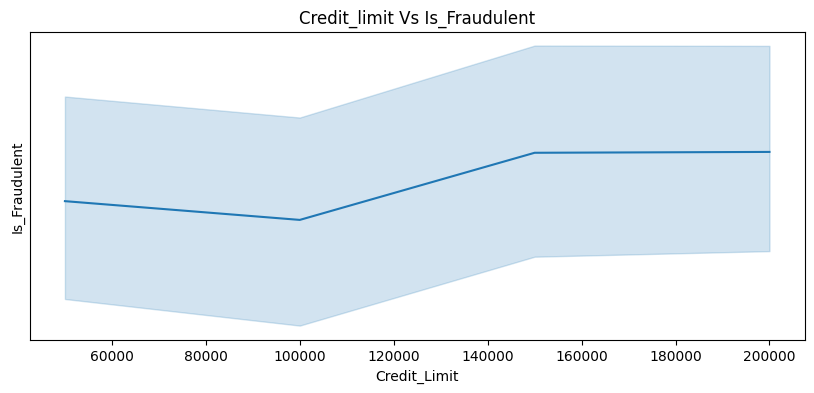

In [10]:
#Conduct bivariate and multivariate analysis to identify potential relationships between the features as well as with the target variable (Is_Fraudulent).

#Bivariate
plt.figure(figsize=(10,4))
sns.lineplot(data = ccfd, x= 'Credit_Limit', y= 'Is_Fraudulent', palette= 'set2')
plt.title('Credit_limit Vs Is_Fraudulent')
plt.show()

observation:

from the above fig., we understood that fraudulent have a higher credit_limit.

<Figure size 1000x400 with 0 Axes>

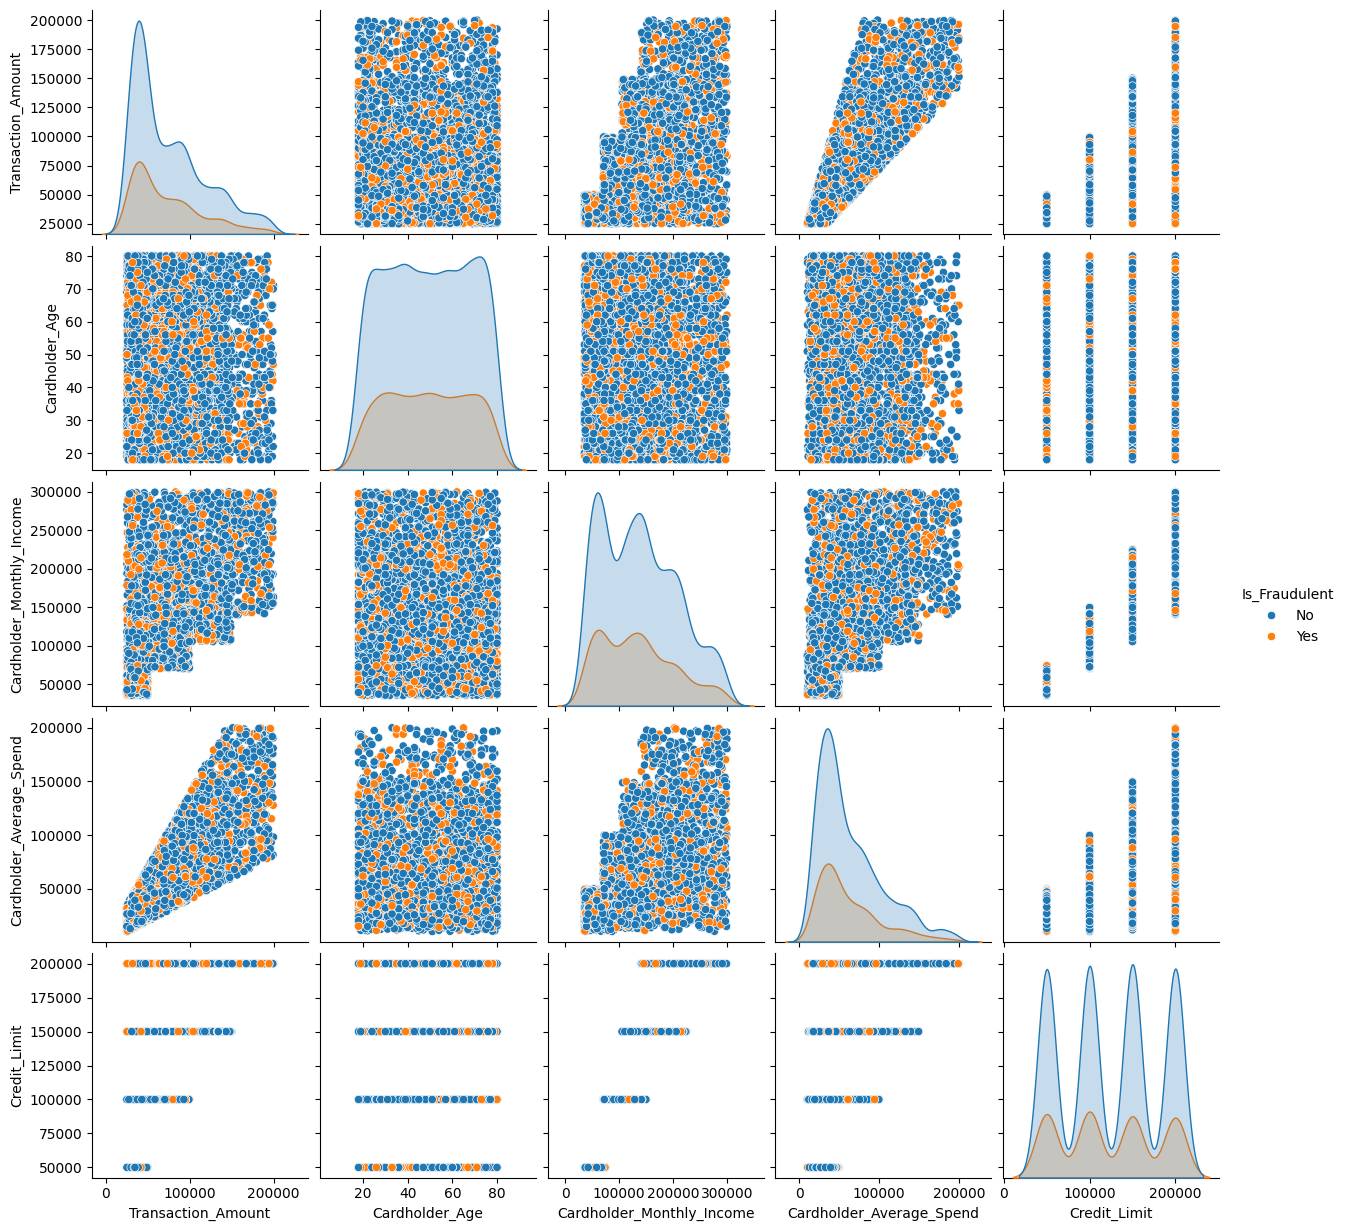

In [11]:
#Multivariate

plt.figure(figsize=(10,4))
sns.pairplot(data= ccfd, hue = 'Is_Fraudulent')
plt.show()

In [12]:
correlation_matrix = ccfd[numerical_col].corr().round()
correlation_matrix

,Transaction_Amount,Cardholder_Age,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit
Transaction_Amount,1.0,-0.0,1.0,1.0,1.0
Cardholder_Age,-0.0,1.0,-0.0,-0.0,-0.0
Cardholder_Monthly_Income,1.0,-0.0,1.0,1.0,1.0
Cardholder_Average_Spend,1.0,-0.0,1.0,1.0,1.0
Credit_Limit,1.0,-0.0,1.0,1.0,1.0


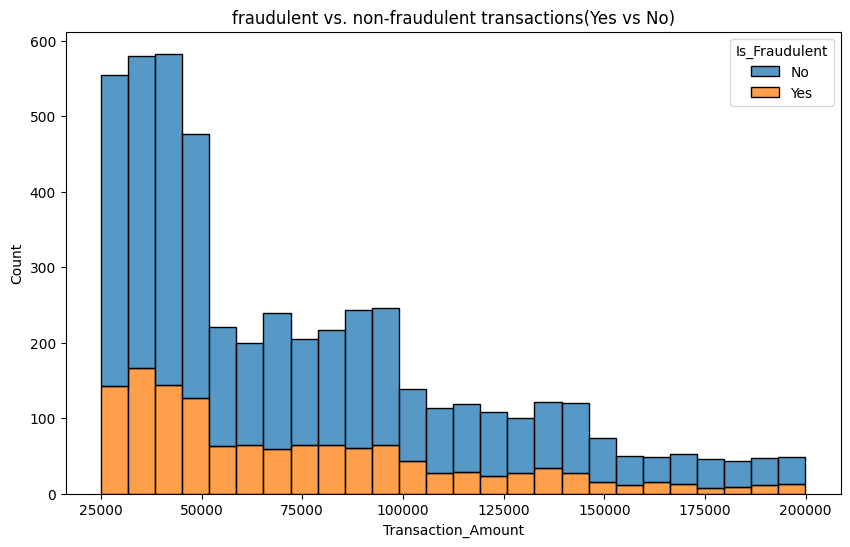

In [13]:
#Visualize the distribution of transaction amounts for fraudulent vs non-fraudulent transactions using histograms or box plots.
plt.figure(figsize=(10,6))
sns.histplot(data= ccfd, x='Transaction_Amount', hue= 'Is_Fraudulent', multiple= 'stack')
plt.title('fraudulent vs. non-fraudulent transactions(Yes vs No)')
plt.show()

observation:

fraudulent transaction amount is higher below 100000, but few in numbers have above 150000 transaction amount.

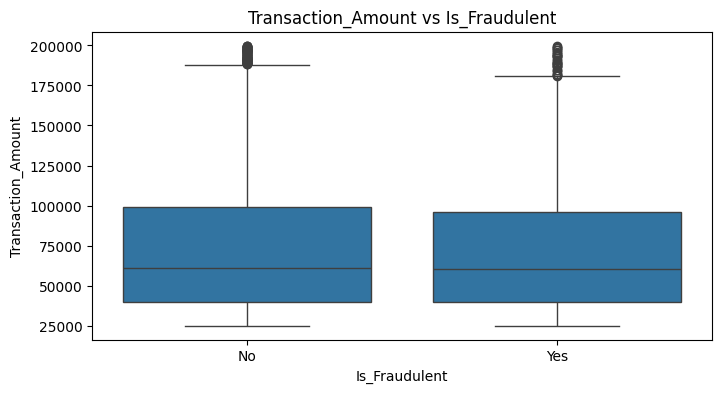

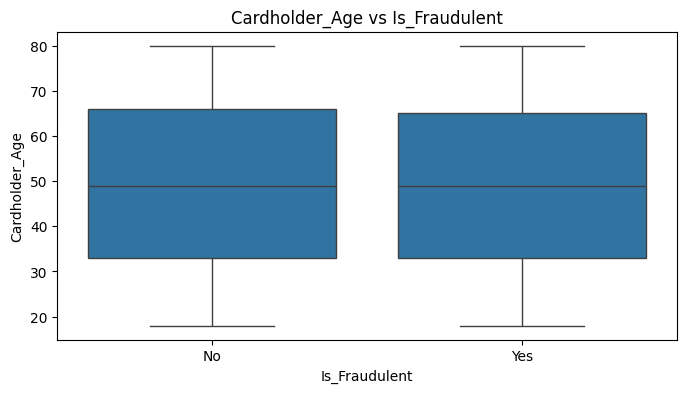

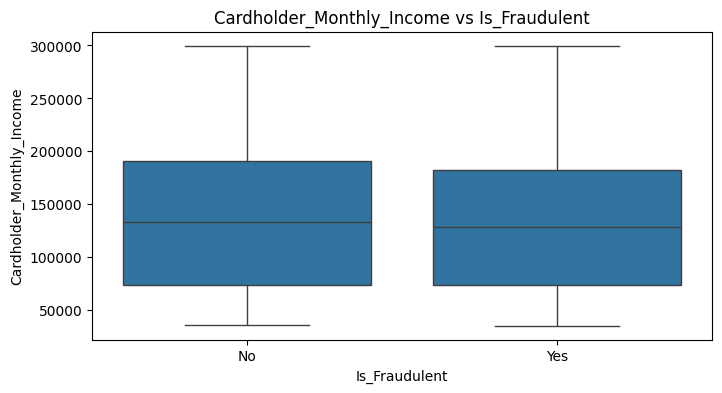

In [14]:
#Investigate whether certain features are more susceptible to fraud.
numerical_features = ['Transaction_Amount', 'Cardholder_Age', 'Cardholder_Monthly_Income']
for features in numerical_features:
  plt.figure(figsize=(8,4))
  sns.boxplot(data= ccfd, x= 'Is_Fraudulent', y= features)
  plt.title(f'{features} vs Is_Fraudulent')
  plt.show()

#Data Preprocessing - Data Cleaning

In [15]:
ccfd.isnull().sum()

,0
Transaction_ID,0
Card_Type,17
Merchant_Category,22
Transaction_Amount,6
Transaction_DateTime,0
Location,0
Region,0
Cardholder_Age,135
Cardholder_Gender,89
Cardholder_Monthly_Income,314


In [16]:
#Handle missing values if any, using appropriate techniques such as KNNImputer; mean or median imputation for numerical features, and mode imputation for categorical features.

from sklearn.impute import KNNImputer, SimpleImputer
numerical_cols = ['Transaction_Amount', 'Cardholder_Monthly_Income','Cardholder_Average_Spend','Credit_Limit']
num_imputer = KNNImputer(n_neighbors= 5)
ccfd[numerical_cols] = num_imputer.fit_transform(ccfd[numerical_cols])

In [17]:
categorical_cols = ['Device_Type', 'Cardholder_Gender', 'Cardholder_Age', 'Merchant_Category', 'Card_Type']
cat_imputer = SimpleImputer(strategy= 'most_frequent')
ccfd[categorical_cols] = cat_imputer.fit_transform(ccfd[categorical_cols])

In [18]:
ccfd.isnull().sum()

,0
Transaction_ID,0
Card_Type,0
Merchant_Category,0
Transaction_Amount,0
Transaction_DateTime,0
Location,0
Region,0
Cardholder_Age,0
Cardholder_Gender,0
Cardholder_Monthly_Income,0


In [19]:
#Check for outliers in numerical features using statistical methods like Z-score or IQR (Interquartile Range) and remove them if necessary to ensure data quality.

Q1 = ccfd[numerical_cols].quantile(0.25)
Q3 = ccfd[numerical_cols].quantile(0.75)

print(f'Q1 : \n {Q1}', end = '\n\n')
print(f'Q3 : \n {Q3}', end = '\n\n')
print(f'ccfd before removing outliers : \n {ccfd.shape}')



Q1 : 
 Transaction_Amount            39745.500
Cardholder_Monthly_Income     73329.500
Cardholder_Average_Spend      33413.485
Credit_Limit                 100000.000
Name: 0.25, dtype: float64

Q3 : 
 Transaction_Amount            98397.0000
Cardholder_Monthly_Income    189088.0000
Cardholder_Average_Spend      84217.0175
Credit_Limit                 150000.0000
Name: 0.75, dtype: float64

ccfd before removing outliers : 
 (5000, 15)


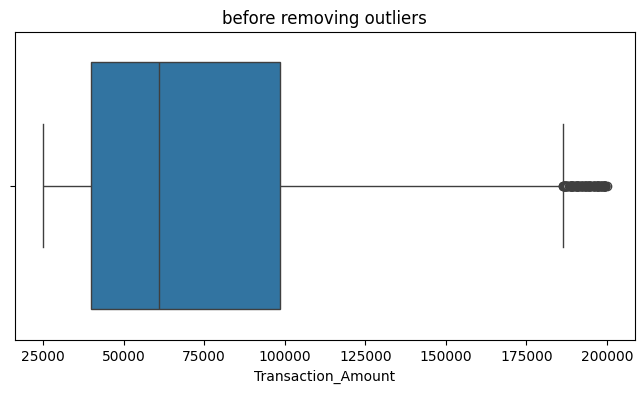

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(data= ccfd, x= 'Transaction_Amount')
plt.title('before removing outliers')
plt.show()

In [21]:
IQR = Q3 - Q1

Lower_bound = Q1 - 1.5 * IQR
Upper_bound = Q3 + 1.5 * IQR

ccfd_removed_outliers = ccfd[(ccfd[numerical_cols] >= (Lower_bound)) & (ccfd[numerical_cols] <= (Upper_bound))]

print(f'IQR : \n {IQR}', end = '\n\n')
print(f'Lower_bound : \n {Lower_bound}', end = '\n\n')
print(f'Upper_bound : \n {Upper_bound}', end = '\n\n')
print(f'ccfd after removing outliers: \n {ccfd_removed_outliers.shape}')

IQR : 
 Transaction_Amount            58651.5000
Cardholder_Monthly_Income    115758.5000
Cardholder_Average_Spend      50803.5325
Credit_Limit                  50000.0000
dtype: float64

Lower_bound : 
 Transaction_Amount           -48231.75000
Cardholder_Monthly_Income   -100308.25000
Cardholder_Average_Spend     -42791.81375
Credit_Limit                  25000.00000
dtype: float64

Upper_bound : 
 Transaction_Amount           186374.25000
Cardholder_Monthly_Income    362725.75000
Cardholder_Average_Spend     160422.31625
Credit_Limit                 225000.00000
dtype: float64

ccfd after removing outliers: 
 (5000, 15)


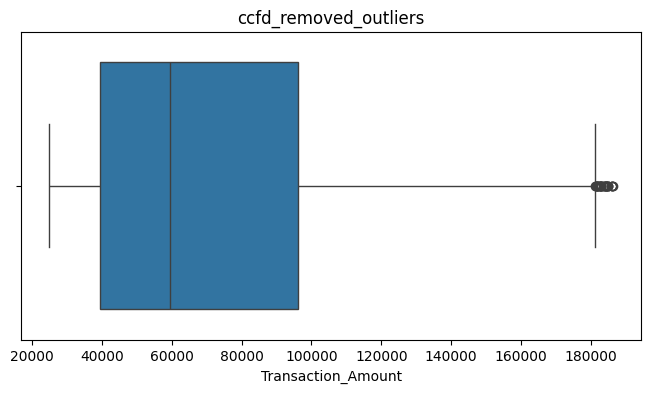

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(data= ccfd_removed_outliers, x= 'Transaction_Amount')
plt.title('ccfd_removed_outliers')
plt.show()

In [23]:
numerical_cols = ['Transaction_Amount', 'Cardholder_Monthly_Income','Cardholder_Average_Spend','Credit_Limit']
numerical_cols

['Transaction_Amount',
 'Cardholder_Monthly_Income',
 'Cardholder_Average_Spend',
 'Credit_Limit']

In [24]:
#Assess skewness in numerical features by calculating the skewness score.

skewness = ccfd[numerical_cols].skew()
skewness


,0
Transaction_Amount,0.966938
Cardholder_Monthly_Income,0.416048
Cardholder_Average_Spend,1.140312
Credit_Limit,0.012063


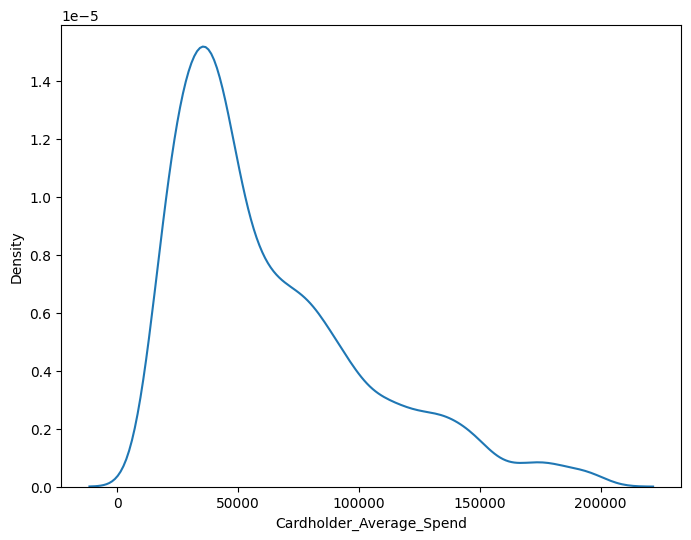

In [25]:
plt.figure(figsize=(8,6))
sns.kdeplot(ccfd['Cardholder_Average_Spend'])
plt.show()

In [26]:
#If any features are highly skewed, consider applying transformations such as square root or log transformation to improve their distribution before scaling, if needed.

#square root transformation

ccfd_sqrt = np.sqrt(ccfd['Cardholder_Average_Spend'])
#skewness score
ccfd_sqrt.skew()

np.float64(0.5921926159988793)

#Feature Engineering

In [27]:
#Identify the categorical features in the dataset.

categorical_features = ccfd.select_dtypes(include = 'O').columns
categorical_features

Index(['Transaction_ID', 'Card_Type', 'Merchant_Category',
       'Transaction_DateTime', 'Location', 'Region', 'Cardholder_Age',
       'Cardholder_Gender', 'Device_Type', 'Day_of_Week', 'Is_Fraudulent'],
      dtype='object')

In [28]:
ccfd_encoded = ccfd.copy()

In [29]:
#Encode categorical features to numerical using techniques like one-hot encoding or label encoding techniques to prepare the data for machine learning algorithms.

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_features:
  ccfd_encoded[col] = le.fit_transform(ccfd_encoded[col])



In [30]:
ccfd = ccfd_encoded
ccfd

,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
0,4413,1,7,27214.0,0,10,0,5,0,94632.0,36369.65,100000.0,4,6,0
1,4138,0,5,83956.0,1,12,3,31,1,148118.0,89179.12,150000.0,1,0,0
2,3323,3,6,193280.0,2,10,0,8,1,210921.0,106668.60,200000.0,1,2,0
3,3775,2,4,167381.0,3,12,3,34,0,148070.0,173155.52,200000.0,1,2,1
4,1925,2,5,81170.0,4,8,1,19,0,174470.0,52713.09,200000.0,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2508,2,1,36508.0,4995,3,1,15,0,63015.0,34192.55,50000.0,0,0,1
4996,1853,0,4,42920.0,4996,2,2,8,0,115859.6,19680.39,100000.0,0,0,0
4997,3487,3,3,33788.0,4997,11,3,38,1,60868.0,33876.96,50000.0,1,2,0
4998,921,2,2,38679.0,4998,2,2,42,1,66948.0,32988.22,50000.0,1,2,0


#Feature Selection

In [31]:
#Select relevant features that have the most impact on predicting fraudulent transactions.

correlation_matrix = ccfd.corr()
correlation_matrix



,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
Transaction_ID,1.000000,0.013285,-0.009008,0.020627,0.014737,0.020656,0.019082,0.001125,-0.000535,0.007159,0.019006,0.010510,-0.004166,0.009378,0.010376
Card_Type,0.013285,1.000000,-0.021039,0.014525,0.021348,-0.005191,-0.020697,-0.008790,-0.025105,0.008072,0.002904,0.010477,0.011610,0.022635,0.004290
Merchant_Category,-0.009008,-0.021039,1.000000,-0.008328,-0.018214,0.000382,0.003659,-0.016648,-0.002060,-0.007002,-0.006003,-0.006416,0.009959,0.014427,-0.013647
Transaction_Amount,0.020627,0.014525,-0.008328,1.000000,0.008609,-0.037930,-0.000316,-0.013032,-0.010445,0.571493,0.839528,0.640013,0.029097,-0.006463,-0.018551
Transaction_DateTime,0.014737,0.021348,-0.018214,0.008609,1.000000,-0.018257,-0.021091,-0.007998,-0.007168,-0.000121,0.008693,0.011589,0.008610,-0.004194,-0.013907
Location,0.020656,-0.005191,0.000382,-0.037930,-0.018257,1.000000,0.030470,-0.002612,0.004826,-0.009461,-0.033234,-0.013083,0.015534,-0.000547,0.010019
Region,0.019082,-0.020697,0.003659,-0.000316,-0.021091,0.030470,1.000000,0.010565,0.006935,0.021939,0.005760,0.012518,-0.014792,-0.003157,-0.037614
Cardholder_Age,0.001125,-0.008790,-0.016648,-0.013032,-0.007998,-0.002612,0.010565,1.000000,0.006105,-0.020756,0.000552,-0.010213,0.016456,0.006961,-0.004104
Cardholder_Gender,-0.000535,-0.025105,-0.002060,-0.010445,-0.007168,0.004826,0.006935,0.006105,1.000000,-0.012200,-0.002389,-0.021262,-0.013528,-0.011380,0.020621
Cardholder_Monthly_Income,0.007159,0.008072,-0.007002,0.571493,-0.000121,-0.009461,0.021939,-0.020756,-0.012200,1.000000,0.534170,0.893517,0.025828,-0.003996,-0.018387


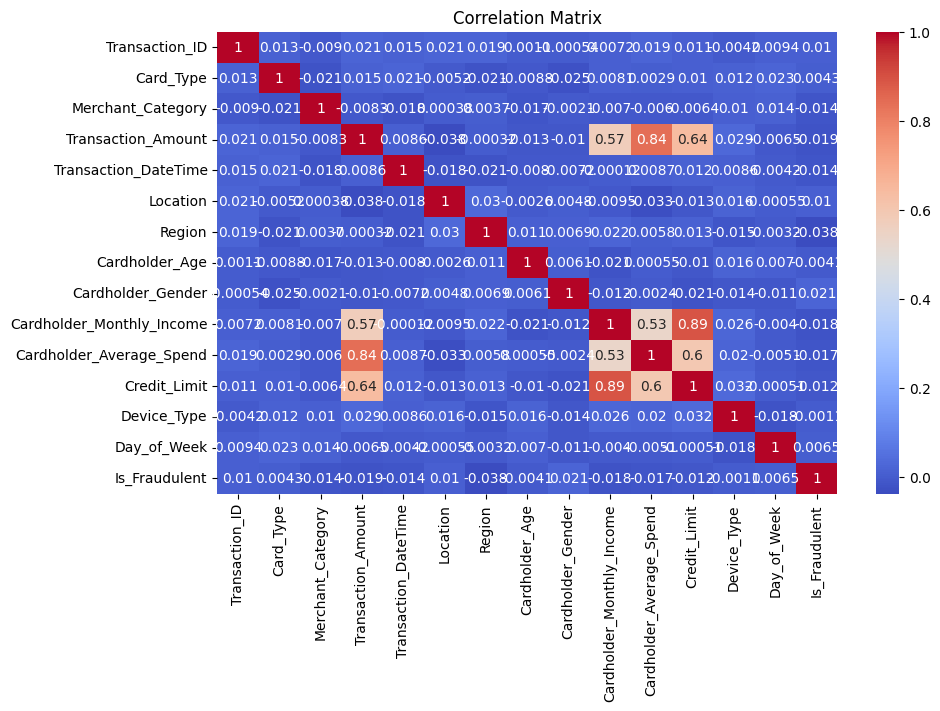

In [32]:
#using heatmap for better visualization
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [33]:
# Identify and remove redundant or irrelevant features that do not contribute significantly to the prediction task.

X = ccfd.drop(['Is_Fraudulent', 'Transaction_DateTime','Region'], axis= 1)
y = ccfd['Is_Fraudulent']

# Split data into training and testing

In [34]:
# Divide the dataset into training and testing sets to evaluate the model's performance.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

print(f'Dataset shape: {ccfd.shape}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

Dataset shape: (5000, 15)
X_train shape: (4000, 12)
X_test shape: (1000, 12)
y_train shape: (4000,)
y_test shape: (1000,)


In [35]:
# Ensure that both sets maintain the same distribution of fraudulent and non-fraudulent transactions to avoid data leakage.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

print(f'Overall distribution:\n {ccfd['Is_Fraudulent'].value_counts(normalize= True)}', end= '\n\n')
print(f'X_train distribution:\n {y_train.value_counts(normalize= True)}', end= '\n\n')
print(f'X_test distribution:\n {y_test.value_counts(normalize= True)}')

Overall distribution:
 Is_Fraudulent
0    0.7336
1    0.2664
Name: proportion, dtype: float64

X_train distribution:
 Is_Fraudulent
0    0.7335
1    0.2665
Name: proportion, dtype: float64

X_test distribution:
 Is_Fraudulent
0    0.734
1    0.266
Name: proportion, dtype: float64


#Feature Scaling

In [36]:
# Scale numerical features to ensure that they have the same magnitude, preventing some features from dominating others during model training.

# Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [37]:
# Normalization

from sklearn.preprocessing import MinMaxScaler
norm_scaler = MinMaxScaler()
x_train_scaled_norm = norm_scaler.fit_transform(X_train)
x_train_scaled_norm = norm_scaler.transform(X_test)

In [38]:
# Common scaling techniques include Min-Max scaling or Standardization (Z-score normalization).

# MinMax Scaling
ccfd_norm = (ccfd - ccfd.min())/(ccfd.max() - ccfd.min())
ccfd_norm.round()

,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
3,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4996,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
# Z-Score Scaling
ccfd_std = (ccfd - ccfd.min())/(ccfd.std())
ccfd_std.round()

,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
0,3.0,1.0,3.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,3.0,3.0,0.0
1,3.0,0.0,2.0,1.0,0.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,1.0,0.0,0.0
2,2.0,3.0,3.0,4.0,0.0,3.0,0.0,0.0,2.0,3.0,2.0,3.0,1.0,1.0,0.0
3,3.0,2.0,2.0,3.0,0.0,3.0,3.0,2.0,0.0,2.0,4.0,3.0,1.0,1.0,2.0
4,1.0,2.0,2.0,1.0,0.0,2.0,1.0,1.0,0.0,2.0,1.0,3.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2.0,2.0,0.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
4996,1.0,0.0,2.0,0.0,3.0,1.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4997,2.0,3.0,1.0,0.0,3.0,3.0,3.0,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0
4998,1.0,2.0,1.0,0.0,3.0,1.0,2.0,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0


#Build the Machine Learning Model

In [47]:
# Import the necessary modules and libraries for building and evaluating machine learning models.

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [44]:
# Define a list or dictionary of classifiers to be evaluated.

classifiers = {
 'Logistic Regression': LogisticRegression(),
 'Decision Tree': DecisionTreeClassifier(),
 'Random Forest': RandomForestClassifier(),
 'K-Nearest Neighbors': KNeighborsClassifier(),
 'Naive Bayes': GaussianNB(),
 'Support Vector Machine': SVC()}


# compute the accuracy score and F1-score for each classifier.

results = {}

for name, clf in classifiers.items():
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  results[name] = {'Accuracy': accuracy, 'F1-Score': f1}

results_df=pd.DataFrame(results).T
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,F1-Score
Logistic Regression,0.734,0.000000
Decision Tree,0.617,0.270476
Random Forest,0.729,0.007326
K-Nearest Neighbors,0.671,0.183623
Naive Bayes,0.734,0.000000
Support Vector Machine,0.734,0.000000


In [45]:
# Select a machine learning algorithm for binary classification with the highest accuracy or F1-score from the above step.

# Select binary classification with the highest accuracy
best_clf = results_df['Accuracy'].idxmax()
best_clf

'Logistic Regression'

In [46]:
# Select binary classification with the F1-score
best_clf = results_df['F1-Score'].idxmax()
best_clf

'Decision Tree'

In [58]:
# Train the selected model using the training dataset and evaluate its performance using appropriate metrics like confusion matrix, accuracy, precision, recall, and F1-score.

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# evaluate its performance using appropriate metrics

from sklearn.metrics import precision_score, recall_score
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:\n{accuracy}', end='\n\n')
print(f'Confusion Matrix:\n{confusion}', end='\n\n')
print(f'Precision: \n{precision}', end='\n\n')
print(f'Recall: \n{recall}', end='\n\n')
print(f'F1-Score:\n{f1}')


Accuracy:
0.612

Confusion Matrix:
[[538 196]
 [192  74]]

Precision: 
0.2740740740740741

Recall: 
0.2781954887218045

F1-Score:
0.27611940298507465


In [59]:
# Validate the model's performance on the testing dataset and interpret the results to assess its effectiveness in detecting fraudulent transactions.

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.73      0.73       734
           1       0.27      0.28      0.28       266

    accuracy                           0.61      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.61      0.61      0.61      1000



Observation:

- Model performance on the testing dataset. Here, we get some results.
- 0 - Non-Fraudulent
- 1 - Fraudulent
- test size = 1000

- Non-Fraudulent:
  - presision: 74% were predicts as non fraud.
  - recall: 73% identified.
  - f1-score: shows a equal and balanced non fraud.

- Fraudulent:
  - presision: 27% were predicts as fraud.
  - recall: 28% identified a fraud.
  - f1-score: equal numbers of fraud.

- over all Accuracy: 61%

- a robust machine learning model capable of accurately detecting credit card transactions in real-time shows us the Non-Fraudulent have good in percentage.